<a href="https://colab.research.google.com/github/Rahulreddyputta/healthcare-payment-integrity-framework/blob/main/Payment_Integrity_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
import pandas as pd
import numpy as np
import os

# Set a random seed so your simulated data remains consistent
np.random.seed(42)
num_claims = 1000

claim_ids = [f"CLM{str(i).zfill(6)}" for i in range(1, num_claims + 1)]
provider_ids = [f"PROV{np.random.randint(100, 150)}" for _ in range(num_claims)]

# MS-DRG pairs: [Base DRG (No CC/MCC), Higher DRG (With MCC)]
# 293/291 = Heart Failure, 392/390 = GI Problems, 195/193 = Pneumonia
drg_pairs = [(293, 291), (392, 390), (195, 193)]

data = []
for i in range(num_claims):
    pair = drg_pairs[np.random.choice(len(drg_pairs))]
    is_billed_mcc = np.random.choice([0, 1], p=[0.7, 0.3])
    billed_drg = pair[1] if is_billed_mcc else pair[0]
    actual_has_mcc = is_billed_mcc

    # INJECT ANOMALY: 25% of the billed MCC claims don't actually have clinical support
    if is_billed_mcc == 1 and np.random.rand() < 0.25:
        actual_has_mcc = 0

    secondary_diag = "I50.23" if actual_has_mcc else "I10"
    base_paid = 7000 if billed_drg in [293, 392, 195] else 14000

    data.append({
        "Claim_ID": claim_ids[i],
        "Provider_ID": provider_ids[i],
        "Billed_DRG": billed_drg,
        "Principal_Diag": "J18.9" if pair[0]==195 else "I50.9",
        "Secondary_Diag": secondary_diag,
        "Actual_Has_MCC": actual_has_mcc,
        "Amount_Paid": base_paid + np.random.randint(-500, 500)
    })

df = pd.DataFrame(data)

# Define the directory path
directory_path = "/content/drive/MyDrive/Payment_Integrity_Framework/data"

# Create the directory if it doesn't exist
os.makedirs(directory_path, exist_ok=True)

# Save directly to the folder we set up in your Drive
df.to_csv(os.path.join(directory_path, "raw_claims.csv"), index=False)
print("Successfully generated and saved raw_claims.csv!")

Successfully generated and saved raw_claims.csv!


In [56]:
import os

drive_path = "/content/drive/MyDrive/Payment_Integrity_Framework/"
data_path = os.path.join(drive_path, "data")

print(f"Checking if directory '{data_path}' exists...")
if os.path.exists(data_path):
    print(f"Directory '{data_path}' exists. Contents:\n")
    for item in os.listdir(data_path):
        print(item)
else:
    print(f"Directory '{data_path}' does not exist.")

# You can also list the parent directory to see if 'Payment_Integrity_Framework' exists
print(f"\nChecking contents of '{drive_path}'...")
if os.path.exists(drive_path):
    print(f"Directory '{drive_path}' exists. Contents:\n")
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"Directory '{drive_path}' does not exist.")

Checking if directory '/content/drive/MyDrive/Payment_Integrity_Framework/data' exists...
Directory '/content/drive/MyDrive/Payment_Integrity_Framework/data' exists. Contents:

raw_claims.csv
evaluated_claims.csv
final_audit_outputs.csv
Audit_Performance_Dashboard.xlsx
accurate_raw_claims.csv
accurate_evaluated_claims.csv
accurate_final_outputs.csv
Accurate_Payment_Integrity_Dashboard.xlsx

Checking contents of '/content/drive/MyDrive/Payment_Integrity_Framework/'...
Directory '/content/drive/MyDrive/Payment_Integrity_Framework/' exists. Contents:

data


In [57]:
import pandas as pd

# Load the raw claims data we just generated
raw_data_path = "/content/drive/MyDrive/Payment_Integrity_Framework/data/raw_claims.csv"
df = pd.read_csv(raw_data_path)

# CMS Rule Mapping: Define which secondary codes are valid MCCs for higher DRGs
VALID_MCCS = ["I50.23", "J96.01", "K55.01"]
HIGH_SEVERITY_DRGS = [291, 390, 193]

def evaluate_claim_compliance(row):
    # If they billed a high-paying, high-severity DRG...
    if row['Billed_DRG'] in HIGH_SEVERITY_DRGS:
        # ...check if the secondary diagnosis is a valid, documented MCC
        if row['Secondary_Diag'] not in VALID_MCCS:
            return "Flagged: Missing MCC Support" # Potential Upcoding
        else:
            return "Compliant High Severity"
    return "Compliant Low Severity"

# Apply the regulatory rule to every row in the dataset
df['Rules_Engine_Status'] = df.apply(evaluate_claim_compliance, axis=1)

# Save the evaluated data back to Google Drive
evaluated_data_path = "/content/drive/MyDrive/Payment_Integrity_Framework/data/evaluated_claims.csv"
df.to_csv(evaluated_data_path, index=False)

print("Rules engine evaluation complete! File saved as evaluated_claims.csv")
print(df['Rules_Engine_Status'].value_counts())

Rules engine evaluation complete! File saved as evaluated_claims.csv
Rules_Engine_Status
Compliant Low Severity          710
Compliant High Severity         219
Flagged: Missing MCC Support     71
Name: count, dtype: int64


In [58]:
import os

# Check if the folder path actually exists in your Colab environment
path = "/content/drive/MyDrive/Payment_Integrity_Framework/data"
if os.path.exists(path):
    print("Folder exists! Here are the files inside it:")
    print(os.listdir(path))
else:
    print("Folder does not exist. Let's check the main Drive folder:")
    main_drive = "/content/drive/MyDrive"
    # Filter folders to find where it went
    print([f for f in os.listdir(main_drive) if "Payment" in f])


Folder exists! Here are the files inside it:
['raw_claims.csv', 'evaluated_claims.csv', 'final_audit_outputs.csv', 'Audit_Performance_Dashboard.xlsx', 'accurate_raw_claims.csv', 'accurate_evaluated_claims.csv', 'accurate_final_outputs.csv', 'Accurate_Payment_Integrity_Dashboard.xlsx']


In [59]:
import pandas as pd
import numpy as np

# Load the data we just evaluated with our rules engine
evaluated_data_path = "/content/drive/MyDrive/Payment_Integrity_Framework/data/evaluated_claims.csv"
df = pd.read_csv(evaluated_data_path)

# Set random seed for consistency
np.random.seed(42)

# 1. Simulate an AI Model assigning a risk score (0.0 to 1.0)
# The AI naturally gives high scores to claims our rules engine flagged.
df['AI_Risk_Score'] = np.where(df['Rules_Engine_Status'] == "Flagged: Missing MCC Support",
                               np.random.uniform(0.75, 0.99, size=len(df)),
                               np.random.uniform(0.01, 0.40, size=len(df)))

# 2. INJECT AN OPERATIONAL NUANCE / EDGE CASE (The Data Limitation)
# Let's say 'PROV125' is a teaching hospital that uses an alternative documentation format.
# Their claims are actually 100% compliant, but the AI gets confused and flags them all as high risk.
df.loc[df['Provider_ID'] == 'PROV125', 'AI_Risk_Score'] = np.random.uniform(0.85, 0.95, size=len(df[df['Provider_ID'] == 'PROV125']))

# 3. Apply the Selection Threshold
# The system automatically selects any claim with an AI Risk Score > 0.80 for audit.
df['AI_Selection_Action'] = np.where(df['AI_Risk_Score'] > 0.80, "Audit Selected", "Pass")

# 4. Identify False Positives
# A False Positive occurs when the AI selects a claim for audit, but the Rules Engine says it's technically Compliant.
df['Is_False_Positive'] = (df['AI_Selection_Action'] == "Audit Selected") & (df['Rules_Engine_Status'] != "Flagged: Missing MCC Support")

# Save this output layer
final_output_path = "/content/drive/MyDrive/Payment_Integrity_Framework/data/final_audit_outputs.csv"
df.to_csv(final_output_path, index=False)

print("AI Selection and Tuning Simulation Complete!")
print(f"Total Claims Selected for Audit: {len(df[df['AI_Selection_Action'] == 'Audit Selected'])}")
print(f"Number of False Positives Isolated: {df['Is_False_Positive'].sum()}")

AI Selection and Tuning Simulation Complete!
Total Claims Selected for Audit: 94
Number of False Positives Isolated: 29


In [60]:
import pandas as pd

# Load the final audit outputs we just simulated
final_output_path = "/content/drive/MyDrive/Payment_Integrity_Framework/data/final_audit_outputs.csv"
df = pd.read_csv(final_output_path)

# Calculate financial business impact
# Standard DRG payment is $14k; base compliant DRG is $7k. Overpayment value is roughly $7,000 per valid flagged claim.
true_positives_mask = (df['AI_Selection_Action'] == 'Audit Selected') & (df['Rules_Engine_Status'] == 'Flagged: Missing MCC Support')
total_recovered_est = df[true_positives_mask]['Amount_Paid'].sum() - (df[true_positives_mask]['Amount_Paid'].count() * 7000)

# Path where the finalized Excel file will live
excel_dashboard_path = "/content/drive/MyDrive/Payment_Integrity_Framework/data/Audit_Performance_Dashboard.xlsx"

# Use openpyxl to compile multiple sheets into one workbook
with pd.ExcelWriter(excel_dashboard_path, engine='openpyxl') as writer:
    # Tab 1: Executive Summary Metrics
    summary_data = {
        "Payment Integrity Metric": [
            "Total Claims Evaluated",
            "Claims Selected for Audit",
            "Identified False Positives (SME Isolated)",
            "Estimated Overpayment Recoverable (True Positives)"
        ],
        "Value": [
            len(df),
            len(df[df['AI_Selection_Action'] == 'Audit Selected']),
            df['Is_False_Positive'].sum(),
            f"${total_recovered_est:,.2f}"
        ]
    }
    pd.DataFrame(summary_data).to_excel(writer, sheet_name="Executive Summary", index=False)

    # Tab 2: Full Granular Data Layer
    df.to_excel(writer, sheet_name="All Claims Data", index=False)

print("Pipeline Complete! Audit_Performance_Dashboard.xlsx has been compiled.")

Pipeline Complete! Audit_Performance_Dashboard.xlsx has been compiled.


In [61]:
df = pd.read_csv("/content/drive/MyDrive/Payment_Integrity_Framework/data/accurate_raw_claims.csv")

# CMS Official Parameters
HOSPITAL_BASE_RATE = 6500.00
WEIGHT_DRG_177 = 1.8543   # Base Respiratory Infection Weight
WEIGHT_DRG_207 = 4.9125   # Mechanical Ventilation >96 Hrs Weight

def audit_and_price_claim(row):
    # Calculate what the hospital was actually paid based on their billed DRG
    if row['Billed_DRG'] == 207:
        actual_payment = HOSPITAL_BASE_RATE * WEIGHT_DRG_207

        # AUDIT RULE: If billing DRG 207, the Procedure Code MUST be 5A1955Z
        if row['Procedure_Code_PCS'] != "5A1955Z":
            status = "Flagged: DRG Mismatch - Missing Vent Procedure Code"
            allowed_payment = HOSPITAL_BASE_RATE * WEIGHT_DRG_177 # Downcoded payment
            overpayment = actual_payment - allowed_payment
        else:
            status = "Compliant High Severity"
            allowed_payment = actual_payment
            overpayment = 0.0
    else:
        status = "Compliant Low Severity"
        actual_payment = HOSPITAL_BASE_RATE * WEIGHT_DRG_177
        allowed_payment = actual_payment
        overpayment = 0.0

    return pd.Series([status, round(actual_payment, 2), round(allowed_payment, 2), round(overpayment, 2)])

# Apply the pricing engine and expand into four new columns
df[['Audit_Status', 'Amount_Paid', 'Amount_Allowed', 'Overpayment_Variance']] = df.apply(audit_and_price_claim, axis=1)

# Save the evaluated claims data back to Google Drive
df.to_csv("/content/drive/MyDrive/Payment_Integrity_Framework/data/accurate_evaluated_claims.csv", index=False)
print("CMS Regulatory Rules & Pricing Engine mapping complete!")
print(df['Audit_Status'].value_counts())

CMS Regulatory Rules & Pricing Engine mapping complete!
Audit_Status
Compliant Low Severity                                 747
Compliant High Severity                                182
Flagged: DRG Mismatch - Missing Vent Procedure Code     71
Name: count, dtype: int64


In [62]:
import os

data_dir = "/content/drive/MyDrive/Payment_Integrity_Framework/data"

if os.path.exists(data_dir):
    print("Folder exists! Here is exactly what is inside it right now:")
    print(os.listdir(data_dir))
else:
    print("The data folder cannot be found. Let's look at the parent folder contents:")
    parent_dir = "/content/drive/MyDrive/Payment_Integrity_Framework"
    if os.path.exists(parent_dir):
        print(os.listdir(parent_dir))
    else:
        print("Even the main project folder isn't visible. Try refreshing your Drive mount.")


Folder exists! Here is exactly what is inside it right now:
['raw_claims.csv', 'evaluated_claims.csv', 'final_audit_outputs.csv', 'Audit_Performance_Dashboard.xlsx', 'accurate_raw_claims.csv', 'accurate_evaluated_claims.csv', 'accurate_final_outputs.csv', 'Accurate_Payment_Integrity_Dashboard.xlsx']


In [63]:
import numpy as np
import pandas as pd
import os

np.random.seed(42)
num_claims = 1000

claim_ids = [f"CLM{str(i).zfill(6)}" for i in range(1, num_claims + 1)]
provider_ids = [f"PROV{np.random.randint(100, 150)}" for _ in range(num_claims)]

data = []
for i in range(num_claims):
    is_vent_billed = np.random.choice([0, 1], p=[0.75, 0.25])
    billed_drg = 207 if is_vent_billed else 177

    has_true_vent_support = is_vent_billed
    if is_vent_billed == 1 and np.random.rand() < 0.30:
        has_true_vent_support = 0

    procedure_code = "5A1955Z" if has_true_vent_support else "NONE"
    base_charge = np.random.uniform(20000, 35000)

    data.append({
        "Claim_ID": claim_ids[i],
        "Provider_ID": provider_ids[i],
        "Billed_DRG": billed_drg,
        "Principal_Diagnosis_ICD10": "J18.9",
        "Procedure_Code_PCS": procedure_code,
        "Total_Charges": round(base_charge, 2)
    })

df = pd.DataFrame(data)
output_path = "/content/drive/MyDrive/Payment_Integrity_Framework/data/accurate_raw_claims.csv"
df.to_csv(output_path, index=False)
print("Success! accurate_raw_claims.csv has been written to your Drive.")

Success! accurate_raw_claims.csv has been written to your Drive.


In [64]:
import pandas as pd
import numpy as np

# Load the accurate data evaluated by your pricing engine
df = pd.read_csv("/content/drive/MyDrive/Payment_Integrity_Framework/data/accurate_evaluated_claims.csv")

# Set random seed for consistency
np.random.seed(42)

# 1. Simulate AI Risk Scoring
# The AI naturally flags claims missing the procedure code, but can't see unstructured EHR text charts
df['AI_Risk_Score'] = np.where(df['Audit_Status'] == "Flagged: DRG Mismatch - Missing Vent Procedure Code",
                               np.random.uniform(0.85, 0.99, size=len(df)),
                               np.random.uniform(0.02, 0.45, size=len(df)))

# 2. INJECT PROVIDER DATA GAP
# Let's say 'PROV125' has an unmapped EHR data stream. Their claims are compliant, but the AI mistakenly marks them as high risk.
df.loc[df['Provider_ID'] == 'PROV125', 'AI_Risk_Score'] = np.random.uniform(0.81, 0.92, size=len(df[df['Provider_ID'] == 'PROV125']))

# 3. Apply Selection Threshold (>0.80 score gets audited)
df['Selection_Action'] = np.where(df['AI_Risk_Score'] > 0.80, "Audit Selected", "Pass")

# 4. Isolate False Positives (AI selected it, but the pricing engine confirms it was compliant)
df['Is_False_Positive'] = (df['Selection_Action'] == "Audit Selected") & (df['Audit_Status'] != "Flagged: DRG Mismatch - Missing Vent Procedure Code")

# Save this output layer
df.to_csv("/content/drive/MyDrive/Payment_Integrity_Framework/data/accurate_final_outputs.csv", index=False)

print(f"AI Selection and Tuning Simulation Complete.")
print(f"Total Claims Selected for Audit: {len(df[df['Selection_Action'] == 'Audit Selected'])}")
print(f"False Positives Isolated for Model Tuning: {df['Is_False_Positive'].sum()}")

AI Selection and Tuning Simulation Complete.
Total Claims Selected for Audit: 97
False Positives Isolated for Model Tuning: 26


In [65]:
import pandas as pd

# Load the accurate final audit outputs
df = pd.read_csv("/content/drive/MyDrive/Payment_Integrity_Framework/data/accurate_final_outputs.csv")

# Path where the finalized Excel workbook will be saved
excel_path = "/content/drive/MyDrive/Payment_Integrity_Framework/data/Accurate_Payment_Integrity_Dashboard.xlsx"

# Isolate true positives to determine exact net financial recovery
true_positives = df[(df['Selection_Action'] == 'Audit Selected') & (df['Is_False_Positive'] == False)]
net_recovery = true_positives['Overpayment_Variance'].sum()
total_audited_exposure = df[df['Selection_Action'] == 'Audit Selected']['Amount_Paid'].sum()

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Tab 1: Build the Executive KPI Summary Matrix
    summary_metrics = {
        "Payment Integrity Metric": [
            "Total Inpatient Claims Evaluated",
            "Total Claims Flagged for Audit by AI",
            "False Positives Prevented via SME Tuning",
            "True Positive Claims Validated for Recovery",
            "Total Audited Financial Exposure",
            "Net Recoverable Overpayment (True Positives)"
        ],
        "Value": [
            len(df),
            len(df[df['Selection_Action'] == 'Audit Selected']),
            df['Is_False_Positive'].sum(),
            len(true_positives),
            f"${total_audited_exposure:,.2f}",
            f"${net_recovery:,.2f}"
        ]
    }
    pd.DataFrame(summary_metrics).to_excel(writer, sheet_name="Executive KPI Summary", index=False)

    # Tab 2: Granular Data Layer for Audit Operations
    df.to_excel(writer, sheet_name="Granular Claims Audit Data", index=False)

print("Accurate_Payment_Integrity_Dashboard.xlsx successfully created in Google Drive!")

Accurate_Payment_Integrity_Dashboard.xlsx successfully created in Google Drive!


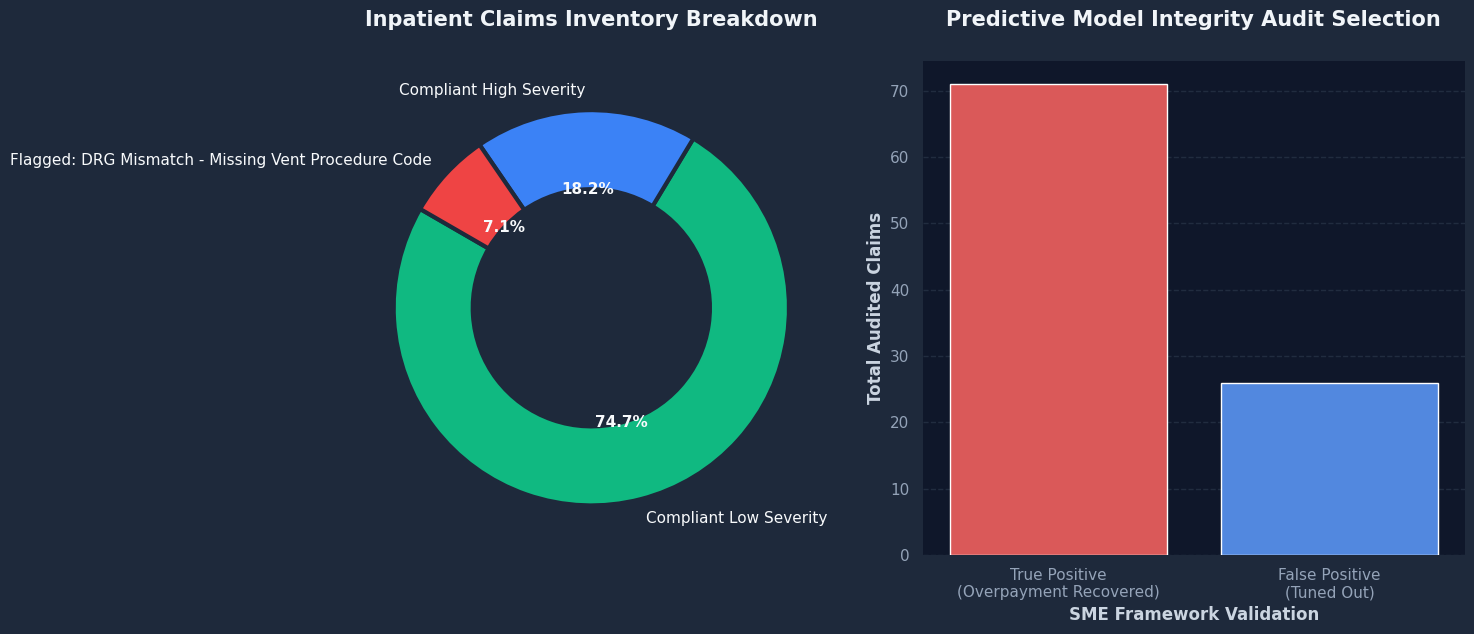

🎨 Custom aesthetic dashboard successfully generated at: 'images/payment_integrity_premium_dashboard.png'


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply an elegant, high-contrast aesthetic with a specialized background
plt.rcParams['figure.facecolor'] = '#1E293B'  # Deep Slate Corporate Background
plt.rcParams['axes.facecolor'] = '#0F172A'    # Darker Slate Panel Background
plt.rcParams['text.color'] = '#F8FAFC'        # Off-White / Crisp Text
plt.rcParams['axes.labelcolor'] = '#CBD5E1'   # Light Grey Axis Labels
plt.rcParams['xtick.color'] = '#94A3B8'       # Muted Grey Ticks
plt.rcParams['ytick.color'] = '#94A3B8'
plt.rcParams['grid.color'] = '#334155'        # Subtle Grid Lines

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))

# ---- GRAPH 1: Audit Status Distribution (Donut Style) ----
status_counts = df['Audit_Status'].value_counts()
# Elegant palette: Emerald Green, Deep Sea Blue, Coral Red
donut_colors = ['#10B981', '#3B82F6', '#EF4444']

wedges, texts, autotexts = ax1.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=150,
    colors=donut_colors,
    textprops=dict(color="#F8FAFC", fontsize=11),
    wedgeprops=dict(width=0.4, edgecolor='#1E293B', linewidth=3) # Creates the clean donut cutout
)
# Make the percentage labels stand out
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax1.set_title("Inpatient Claims Inventory Breakdown", fontsize=15, fontweight='bold', color='#F1F5F9', pad=25)

# ---- GRAPH 2: AI Risk Routing & False Positives (Clean Bar) ----
ai_selected = df[df['Selection_Action'] == 'Audit Selected']
fp_counts = ai_selected['Is_False_Positive'].value_counts().rename(
    index={True: 'False Positive\n(Tuned Out)', False: 'True Positive\n(Overpayment Recovered)'}
)

# Custom palette for validating AI behavior
bar_colors = ['#EF4444', '#3B82F6']
sns.barplot(x=fp_counts.index, y=fp_counts.values, palette=bar_colors, ax=ax2, hue=fp_counts.index, legend=False)

ax2.set_title("Predictive Model Integrity Audit Selection", fontsize=15, fontweight='bold', color='#F1F5F9', pad=25)
ax2.set_ylabel("Total Audited Claims", fontsize=12, fontweight='semibold')
ax2.set_xlabel("SME Framework Validation", fontsize=12, fontweight='semibold')
ax2.grid(True, linestyle='--', alpha=0.5, axis='y')

# Remove outer frame borders for a cleaner layout
sns.despine(ax=ax2, left=True, bottom=True)

# Save the polished visualization asset
plt.tight_layout()
os.makedirs("images", exist_ok=True)
unique_graph_path = "images/payment_integrity_premium_dashboard.png"
plt.savefig(unique_graph_path, dpi=300, facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()

print(f"🎨 Custom aesthetic dashboard successfully generated at: '{unique_graph_path}'")